<a href="https://colab.research.google.com/github/3l6j9/Intersnhip-AI-ML-2026/blob/main/Day%205/Assignment_Day_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer,PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('/content/bbc_news_text_complexity_summarization.csv')

In [23]:
nltk.download('punk')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Error loading punk: Package 'punk' not found in index
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [24]:
stop_words = set(stopwords.words("english"))
print(stop_words)
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

{'which', 'but', 'during', 'ma', 'below', 'hasn', 'mustn', 'm', "we'd", 'hers', 'when', 'did', "they'll", 'our', 'too', 'between', 'him', 'nor', 'yours', 'shouldn', "i'd", 'as', 'them', "we're", 'does', 'out', "he'd", "couldn't", 'to', 'should', 'other', "hasn't", 'he', 'those', 'each', 'what', 'are', 'above', "don't", 'off', 'so', 'weren', 'isn', 'were', 'more', 'before', "isn't", 'my', "wouldn't", 'been', 'have', 'his', 've', 'its', 'himself', 'while', 'they', 'wasn', "you're", "it's", 'doing', 'is', 'most', "he'll", 'it', 'if', 'has', "i'm", 'such', 'over', 'didn', "i'll", 'having', "it'll", 'ain', "you've", 'only', 'after', 'themselves', "wasn't", 'once', "that'll", "doesn't", 'i', 'll', 'won', 'we', "we've", 'that', 'these', "they've", 'until', 'itself', 'a', 'and', 'can', 'in', 'wouldn', 'further', 'against', "she'd", 'myself', 's', 'the', 'under', "didn't", 'aren', 're', 'yourself', 'couldn', 'by', 'theirs', "she'll", 'was', 'their', 'now', 'don', 'for', 'about', 'd', 'had', "we

In [25]:
def process_text(text):
  word_tokens = word_tokenize(text)
  filtered_tokens = [word for word in word_tokens if word.lower() not in stop_words]
  lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
  return{
      "Orginal_Text": text,
      "Word_Tokens": word_tokens,
      "Filtered_Tokens": filtered_tokens,
      "Lemmatized_Tokens": lemmatized_tokens,
  }

In [26]:
df


,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...
...,...,...,...,...,...,...,...
2122,New consoles promise big problems\n\nMaking ga...,tech,52,60.85,9.20,Instead of employing lots of artists to create...,Mr Wright said that enabling players to devise...
2123,BT program to beat dialler scams\n\nBT is intr...,tech,17,56.29,9.23,If a bill rises substantially above its usual ...,BT is introducing two initiatives to help beat...
2124,Be careful how you code\n\nA new European dire...,tech,45,56.29,8.73,"If it gets its way, the Dutch government will ...",A new European directive could put software wr...
2125,US cyber security chief resigns\n\nThe man mak...,tech,16,47.42,9.14,Amit Yoran was director of the National Cyber ...,The man making sure US computer networks are s...


In [27]:
results = df["text"].apply(process_text)
process_df = pd.DataFrame(results.tolist())
print(process_df.head())
processed_file_path = "processed_nlp_dataset.csv"
process_df.to_csv(processed_file_path, index=False)
print(f"Processed data saved to {processed_file_path}")

                                        Orginal_Text  \
0  Ad sales boost Time Warner profit\n\nQuarterly...   
1  Dollar gains on Greenspan speech\n\nThe dollar...   
2  Yukos unit buyer faces loan claim\n\nThe owner...   
3  High fuel prices hit BA's profits\n\nBritish A...   
4  Pernod takeover talk lifts Domecq\n\nShares in...   

                                         Word_Tokens  \
0  [Ad, sales, boost, Time, Warner, profit, Quart...   
1  [Dollar, gains, on, Greenspan, speech, The, do...   
2  [Yukos, unit, buyer, faces, loan, claim, The, ...   
3  [High, fuel, prices, hit, BA, 's, profits, Bri...   
4  [Pernod, takeover, talk, lifts, Domecq, Shares...   

                                     Filtered_Tokens  \
0  [Ad, sales, boost, Time, Warner, profit, Quart...   
1  [Dollar, gains, Greenspan, speech, dollar, hit...   
2  [Yukos, unit, buyer, faces, loan, claim, owner...   
3  [High, fuel, prices, hit, BA, 's, profits, Bri...   
4  [Pernod, takeover, talk, lifts, Domecq, Sha

In [28]:
text_data = pd.read_csv('/content/processed_nlp_dataset.csv')
vectorizer =  CountVectorizer()
bow_matrix = vectorizer.fit_transform(text_data)
bow_df = pd.DataFrame(bow_matrix.toarray(),columns = vectorizer.get_feature_names_out())

In [29]:
print('Bag of Words Representation')
print(bow_df)

Bag of Words Representation
   filtered_tokens  lemmatized_tokens  orginal_text  word_tokens
0                0                  0             1            0
1                0                  0             0            1
2                1                  0             0            0
3                0                  1             0            0


In [30]:
bow_df.to_csv('bag_of_words.csv',index=False)

In [31]:
def Lematize_text(Text):
  tokens = word_tokenize(Text)
  filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
  return ' '.join([lemmatizer.lemmatize(word) for word in filtered_tokens])

In [32]:
def stem_text(Text):
  tokens = word_tokenize(str(Text))
  return ' '.join([stemmer.stem(word) for word in tokens])

In [33]:
df['leammatized_text'] = df['text'].apply(Lematize_text)
df['stemed_text'] = df['text'].apply(stem_text)

In [34]:
output_path = 'lemmatization vs stemming.csv'
df.to_csv(output_path,index=False)

In [35]:
new_text_data = " ".join(df['text'].dropna())

In [36]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(new_text_data)

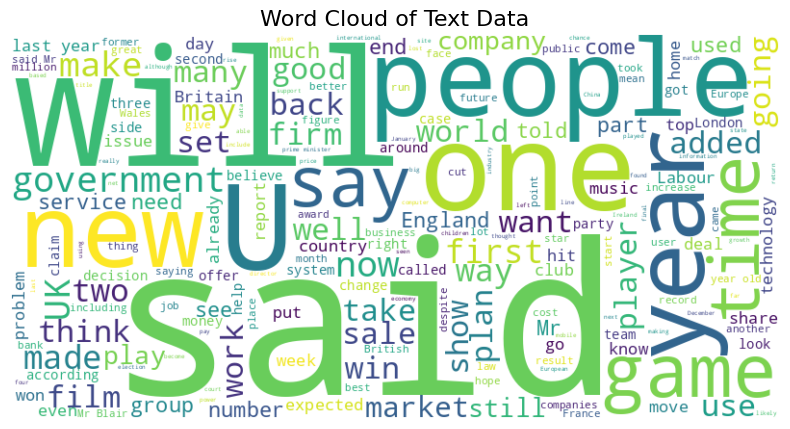

In [37]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Text Data',fontsize=16)
plt.show()

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the text data to get the TF-IDF matrix
# Assuming 'df' and 'text' column are available from previous cells
tfidf_matrix = vectorizer.fit_transform(df['text'])

print("Vocabulary:")
print(vectorizer.vocabulary_)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print("\nTF-IDF Matrix:")
print(tfidf_df)

# Display shape
print("\nMatrix Shape:")
print(tfidf_matrix.shape)

Vocabulary:
{'ad': 1750, 'sales': 23062, 'boost': 4349, 'time': 26665, 'warner': 28502, 'profit': 20825, 'quarterly': 21204, 'profits': 20832, 'at': 2994, 'us': 27901, 'media': 17064, 'giant': 11826, 'timewarner': 26677, 'jumped': 14933, '76': 1249, 'to': 26730, '13bn': 184, '600m': 1105, 'for': 11102, 'the': 26462, 'three': 26566, 'months': 17692, 'december': 7736, 'from': 11377, '639m': 1136, 'year': 29256, 'earlier': 9183, 'firm': 10842, 'which': 28749, 'is': 14510, 'now': 18557, 'one': 18837, 'of': 18726, 'biggest': 3963, 'investors': 14406, 'in': 13801, 'google': 12066, 'benefited': 3816, 'high': 13002, 'speed': 24836, 'internet': 14299, 'connections': 6653, 'and': 2429, 'higher': 13005, 'advert': 1885, 'said': 23041, 'fourth': 11224, 'quarter': 21203, 'rose': 22793, '11': 106, '1bn': 461, '10': 68, '9bn': 1466, 'its': 14571, 'were': 28694, 'buoyed': 4868, 'by': 4980, 'off': 18730, 'gains': 11534, 'offset': 18758, 'dip': 8384, 'bros': 4713, 'less': 15809, 'users': 27919, 'aol': 25

In [40]:
vectorizer = TfidfVectorizer()

In [42]:
tfidf_matrix = vectorizer.fit_transform(df['text'])

In [44]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("\nTF-IDF Matrix:")
print(tfidf_df)


TF-IDF Matrix:
       00       000  0001  000bn  000m  000s  000th  001  001and  001st  ...  \
0     0.0  0.021017   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
1     0.0  0.000000   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
2     0.0  0.000000   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
3     0.0  0.019212   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
4     0.0  0.000000   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
...   ...       ...   ...    ...   ...   ...    ...  ...     ...    ...  ...   
2122  0.0  0.011843   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
2123  0.0  0.043571   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
2124  0.0  0.000000   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
2125  0.0  0.000000   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   
2126  0.0  0.005673   0.0    0.0   0.0   0.0    0.0  0.0     0.0    0.0  ...   

      zooms  zooropa  z

In [45]:
print("\nMatrix Shape:")
print(tfidf_matrix.shape)


Matrix Shape:
(2127, 29421)
